In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# 1. PARAMÉTRAGE DES CHEMINS
PATH_DATA = "../data"

# 2. FONCTION D'EXTRACTION HARMONISÉE (sr=22050 fixe pour tout le monde !)
def extraire_mfcc(chemin_fichier, n_mfcc=26):
    try:
        # On force à 22050 Hz pour que l'IRMAS et Philharmonia parlent la même langue mathématique
        y, sr = librosa.load(chemin_fichier, duration=None, sr=22050) 
        if len(y) == 0:
            return None
        # Calcul des MFCC avec le sr harmonisé
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        return None

In [ ]:
def extraire_features_boostees(chemin_fichier):
    try:
        y, sr = librosa.load(chemin_fichier, duration=None, sr=22050) 
        if len(y) == 0: return None
        
        # 1. Les MFCC (on monte à 26)
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=26).T, axis=0)
        
        # 2. Le Spectral Centroid (Brillance du son)
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr).T, axis=0)
        
        # 3. Les Chromas (Contenu harmonique / notes)
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
        
        # On combine tout en un seul vecteur de caractéristiques
        return np.concatenate((mfccs, centroid, chroma))
    except:
        return None

In [ ]:
# 3. SCAN DES FICHIERS
extensions = ('/**/*.wav', '/**/*.mp3')
fichiers_audio = []
for ext in extensions:
    fichiers_audio.extend(glob.glob(PATH_DATA + ext, recursive=True))

print(f"{len(fichiers_audio)} fichiers détectés. Extraction des caractéristiques physiques du son...")

donnees_audio = []
labels_instruments = []

for index, chemin_complet in enumerate(fichiers_audio):
    chemin_normalise = os.path.normpath(chemin_complet).replace('\\', '/')
    parties_chemin = chemin_normalise.split('/')
    
    is_irmas_testing = "TestingData" in chemin_normalise
    instruments_du_fichier = []
    
    if is_irmas_testing:
        chemin_txt = os.path.splitext(chemin_normalise)[0] + ".txt"
        if os.path.exists(chemin_txt):
            with open(chemin_txt, 'r') as f:
                instruments_du_fichier = [ligne.strip() for ligne in f.readlines() if ligne.strip()]
        else:
            continue
    else:
        instruments_du_fichier = [parties_chemin[-2]]
    
    features = extraire_mfcc(chemin_normalise)
    
    if features is not None:
        for inst in instruments_du_fichier:
            donnees_audio.append(features)
            labels_instruments.append(inst)

    if (index + 1) % 2000 == 0:
        print(f"{index + 1}/{len(fichiers_audio)} fichiers traités...")

23262 fichiers détectés. Extraction des caractéristiques physiques du son...


c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2000/23262 fichiers traités...
4000/23262 fichiers traités...
6000/23262 fichiers traités...
8000/23262 fichiers traités...
10000/23262 fichiers traités...
12000/23262 fichiers traités...
14000/23262 fichiers traités...


c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1728
  warnings.warn(


16000/23262 fichiers traités...
18000/23262 fichiers traités...


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_31632\1217543886.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(chemin_fichier, duration=None, sr=22050)
c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


20000/23262 fichiers traités...
22000/23262 fichiers traités...


In [ ]:
# 4. CONVERSION
X_audio = np.array(donnees_audio)
y_instruments = np.array(labels_instruments)

In [ ]:
dictionnaire_synonymes = {
    'sax': 'saxophone',
    'tru': 'trumpet',
    'vio': 'violin',
    'gac': 'guitar',
    'gel': 'guitar',
    'guitar': 'guitar',
    'pia': 'piano',
    'flu': 'flute',
    'cla': 'clarinet',
    'cel': 'cello',      
    'voi': 'voice'       
}

# Ici, ta cible s'appelle y_instruments ou y, on applique le remplacement dessus
y_instruments = pd.Series(labels_instruments).replace(dictionnaire_synonymes).values

# On vérifie le nombre de classes uniques restantes
print(f"Nombre de classes après fusion : {len(np.unique(y_instruments))}")

Nombre de classes après fusion : 23


In [ ]:
# 5. SÉPARATION TRAIN / TEST (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_audio, y_instruments, test_size=0.2, random_state=42, stratify=y_instruments
)

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [25, 30, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3, # Validation croisée en 3 plis
    scoring='accuracy',
    n_jobs=-1
)

print("Recherche des meilleurs paramètres en cours...")
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")
model_application = grid_search.best_estimator_

Recherche des meilleurs paramètres en cours...
Meilleurs paramètres trouvés : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
# 6. ENTRAÎNEMENT DU RANDOM FOREST EN PROFONDEUR

print("Entraînement du modèle supervisé sur les fréquences audio...")
model_application = RandomForestClassifier(
    n_estimators= 300,
    max_depth= None,
    min_samples_split= 2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
model_application.fit(X_train_resampled, y_train_resampled)
print("Modèle entraîné !")

Entraînement du modèle supervisé sur les fréquences audio...
Modèle entraîné !


ACCURACY FINALE DE TON APPLICATION : 72.97%
=== RAPPORT DE CLASSIFICATION ===
               precision    recall  f1-score   support

        banjo       0.76      0.87      0.81        15
bass clarinet       0.98      1.00      0.99       189
      bassoon       0.91      1.00      0.95       144
        cello       0.83      0.76      0.79       278
     clarinet       0.83      0.79      0.81       283
contrabassoon       0.93      0.99      0.96       142
  cor anglais       0.91      0.99      0.95       138
  double bass       0.90      0.99      0.94       170
        flute       0.85      0.70      0.77       298
  french horn       0.91      0.98      0.94       130
       guitar       0.54      0.49      0.51       596
     mandolin       0.79      0.94      0.86        16
         oboe       0.94      0.96      0.95       119
          org       0.45      0.63      0.52       209
   percussion       0.92      0.80      0.86        30
        piano       0.43      0.47      0

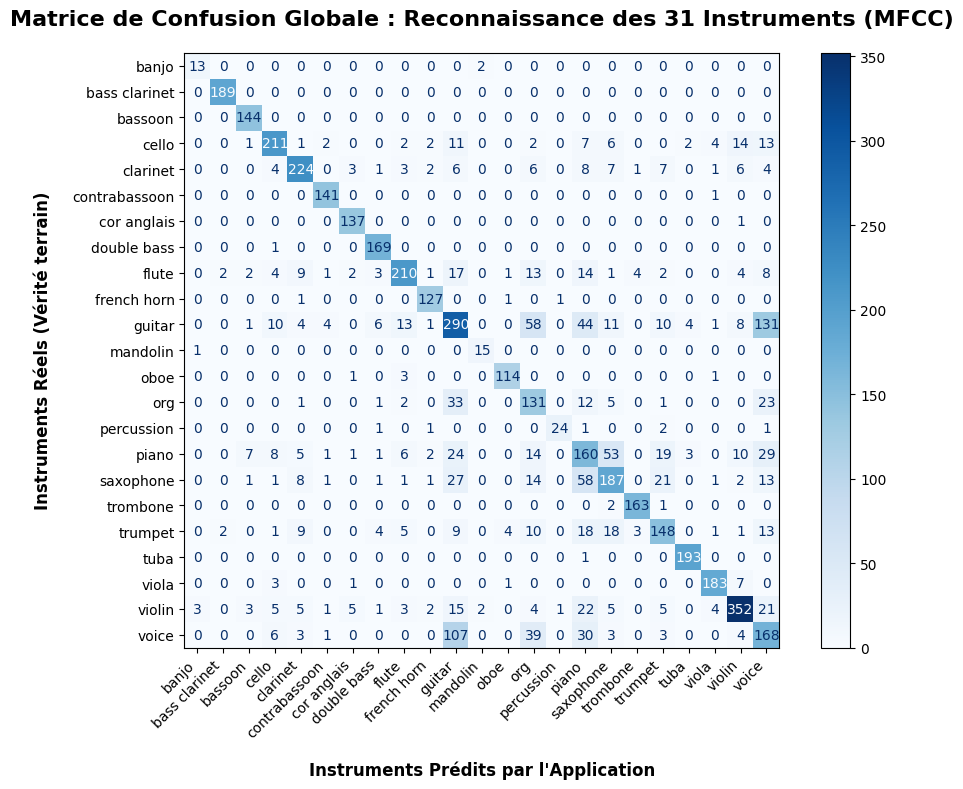

In [ ]:
# 7. ÉVALUATION ET MATRICE DE CONFUSION
y_pred = model_application.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"ACCURACY FINALE DE TON APPLICATION : {accuracy:.2%}")
print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

# Affichage de la vraie matrice globale
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    ax=ax, 
    cmap='Blues', 
    xticks_rotation=45
    )
plt.title("Matrice de Confusion Globale : Reconnaissance des 31 Instruments (MFCC)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Instruments Prédits par l'Application", fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel("Instruments Réels (Vérité terrain)", fontsize=12, fontweight='bold', labelpad=15)

# --- L'ASTUCE POUR NETTOYER LE BAS DU GRAPHIQUE ---
# On applique une rotation à 45 degrés et on aligne le texte par la droite (ha='right')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Désactiver la grille blanche par défaut de seaborn qui peut couper les cases
plt.grid(False)

# Ajustement parfait des marges pour que rien ne soit coupé au moment de l'affichage ou de l'enregistrement
plt.tight_layout()
plt.show()